<a href="https://colab.research.google.com/github/Dvitee/Task-5/blob/main/task_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Task 5: Tree-Based Classification on Heart Disease Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


In [2]:
# Load Dataset
df = pd.read_csv("heart.csv")

In [3]:
print("🔍 Dataset Shape:", df.shape)
print("🔍 Columns:", df.columns.tolist())
print(df.head())

🔍 Dataset Shape: (1025, 14)
🔍 Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [4]:
X = df.drop(columns=['target'])
y = df['target']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [6]:
dtree = DecisionTreeClassifier(max_depth=4, random_state=42)
dtree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

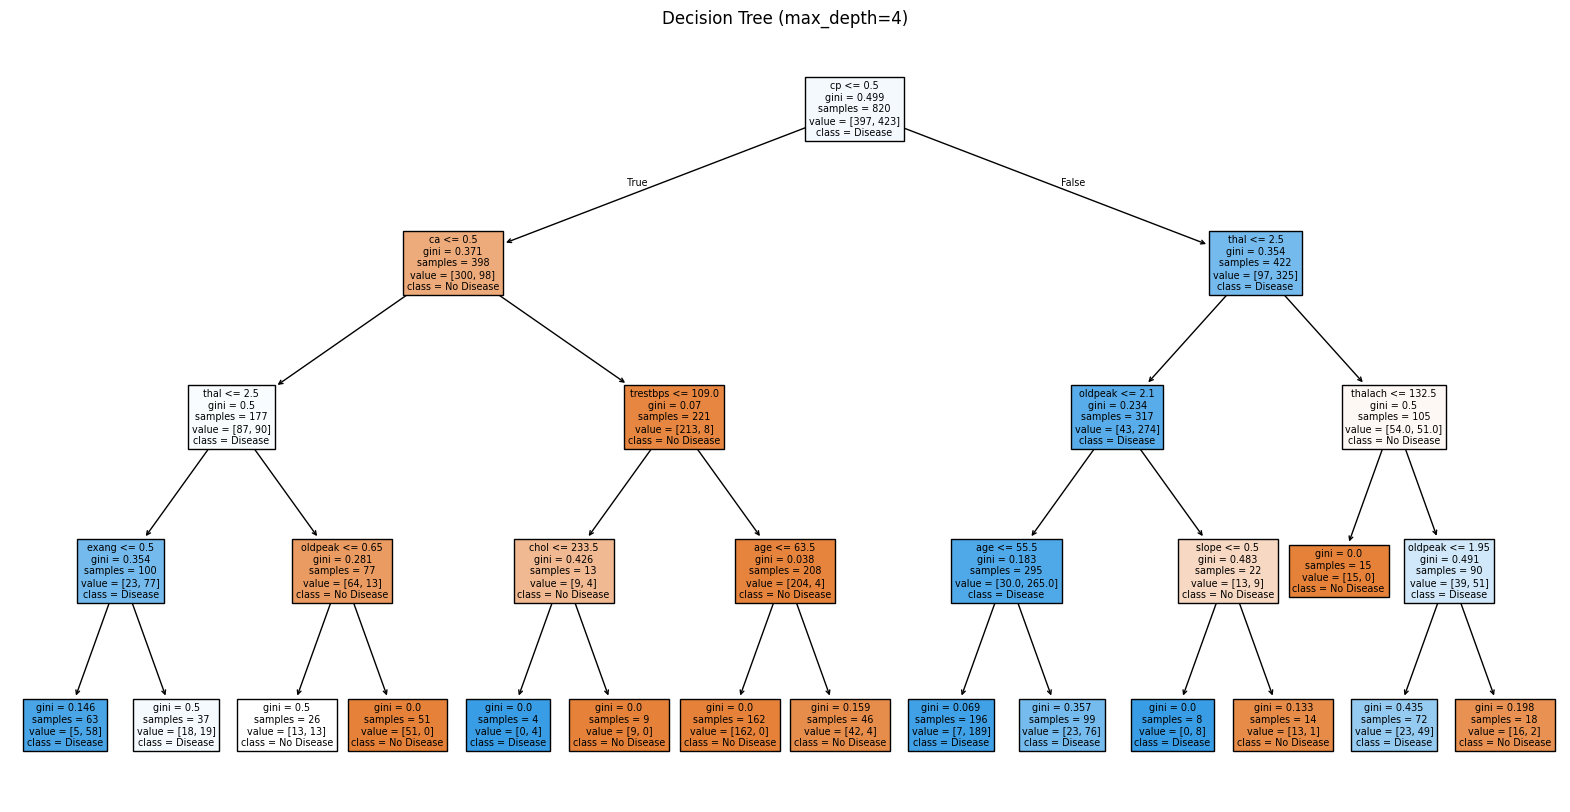

In [7]:
plt.figure(figsize=(20, 10))
plot_tree(dtree, feature_names=X.columns, class_names=['No Disease', 'Disease'], filled=True)
plt.title("Decision Tree (max_depth=4)")
plt.show()

In [8]:
y_pred_dt = dtree.predict(X_test)
print("\n✅ Decision Tree Evaluation:")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))


✅ Decision Tree Evaluation:
[[71 31]
 [10 93]]
              precision    recall  f1-score   support

           0       0.88      0.70      0.78       102
           1       0.75      0.90      0.82       103

    accuracy                           0.80       205
   macro avg       0.81      0.80      0.80       205
weighted avg       0.81      0.80      0.80       205

Accuracy: 0.8


In [9]:
depths = range(1, 21)
train_scores = []
test_scores = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

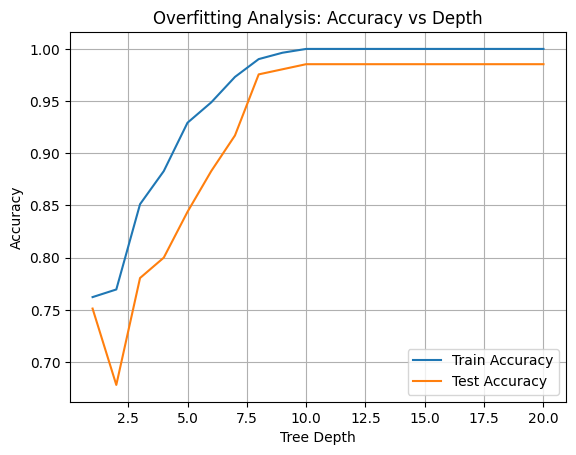

In [10]:
plt.plot(depths, train_scores, label='Train Accuracy')
plt.plot(depths, test_scores, label='Test Accuracy')
plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Analysis: Accuracy vs Depth")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [12]:
y_pred_rf = rf.predict(X_test)
print("\n✅ Random Forest Evaluation:")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))


✅ Random Forest Evaluation:
[[102   0]
 [  3 100]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

Accuracy: 0.9853658536585366


In [13]:
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

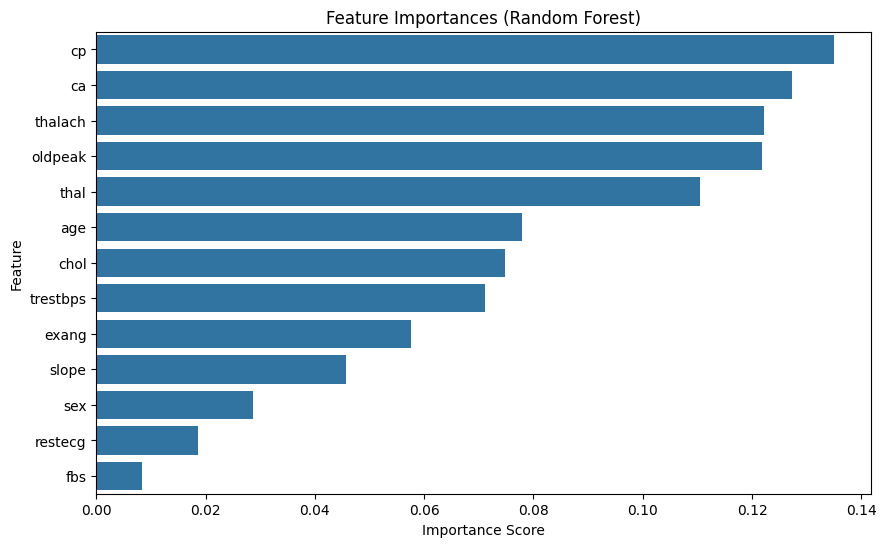

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

In [15]:
cv_scores = cross_val_score(rf, X, y, cv=5)
print(f"\n✅ Cross-Validation Accuracy (5-fold): {cv_scores.mean():.4f}")


✅ Cross-Validation Accuracy (5-fold): 0.9971


# interview questions

## 1. How does a decision tree work?

A decision tree is a flowchart-like structure where internal nodes represent tests on features, branches represent outcomes, and leaf nodes represent class labels.

The algorithm selects features to split the data based on a criterion like **information gain** or **Gini impurity**. It recursively partitions the dataset into subsets to improve class purity at each level.

---

## 2. What is entropy and information gain?

### Entropy

Entropy measures the amount of disorder or impurity in a dataset. In binary classification:

$$
\text{Entropy}(S) = -p_+ \log_2(p_+) - p_- \log_2(p_-)
$$

Where:
- \( p_+ \) = proportion of positive examples  
- \( p_- \) = proportion of negative examples

### Information Gain

Information Gain is the reduction in entropy after a dataset is split on a feature.

$$
\text{IG}(S, A) = \text{Entropy}(S) - \sum_{v \in \text{values}(A)} \frac{|S_v|}{|S|} \cdot \text{Entropy}(S_v)
$$

Where:
- \( A \) is the attribute being split
- \( S_v \) is the subset for value \( v \) of attribute \( A \)

---

## 3. How is random forest better than a single tree?

A random forest is an ensemble of decision trees trained on different subsets of the data and features.

**Advantages over a single tree**:
- Reduces overfitting
- Increases accuracy
- More stable and robust to noise
- Handles missing data better

Random forests combine the predictions of multiple trees, often by majority voting (classification) or averaging (regression), leading to better generalization.

---

## 4. What is overfitting and how do you prevent it?

**Overfitting** occurs when a model learns patterns specific to the training data, including noise, which hurts generalization to unseen data.

### In decision trees, overfitting can be reduced by:
- Limiting `max_depth`
- Setting `min_samples_split` or `min_samples_leaf`
- Using pruning techniques
- Using ensemble methods like Random Forest or Gradient Boosting

A **shallower tree** generalizes better, while a deep tree may memorize training data.

---

## 5. What is bagging?

**Bagging (Bootstrap Aggregating)** is an ensemble technique that trains multiple models on different bootstrapped samples of the dataset (sampling with replacement).

Each model votes (classification) or averages (regression) its prediction:

- Reduces variance
- Improves generalization
- Forms the core of the **Random Forest** algorithm



## 6. How do you visualize a decision tree?

In Scikit-learn, a trained decision tree can be visualized using the `plot_tree` function.

### Example:

```python
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=["No Disease", "Disease"], filled=True)
plt.title("Decision Tree Visualization")
plt.show()


This plot shows:

Which features are used at each node

Thresholds for splitting

Impurity (e.g., Gini or Entropy)

Number of samples per node

Predicted class at each leaf

##7. How do you interpret feature importance?

Tree-based models like Decision Trees and Random Forests can measure the importance of each feature.

Feature importance is based on how much each feature reduces impurity (e.g., Gini or entropy) across all trees in the forest.

Code Example:

```python
Copy
Edit
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()



Interpretation:
Features with higher scores are more influential in making decisions.

Features with very low importance may be dropped in future iterations or require transformation.

##8. What are the pros and cons of Random Forests?

Pros:

-Works well for both classification and regression.

-Handles high-dimensional data efficiently.

-Reduces overfitting by combining many trees.

-Automatically estimates feature importance.

-Can handle missing values (in some implementations).

-Less sensitive to outliers and noise than individual decision trees.

Cons:

-Slower training and prediction than a single decision tree.

-Requires more memory due to many trees.

-Less interpretable than a single decision tree.

-May not perform well on very sparse or extremely high-dimensional datasets (e.g., text data).